<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/fluidsandneqsim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gas flow through valves, fittings, and an orifice plate

This tutorial combines NeqSim thermodynamics and process equipment with transparent hydraulic
calculations from the open-source `fluids` package.

**Intended audience.** Process, flow-assurance, and mechanical engineers who need a reproducible
first-pass pressure-loss or control-valve screen.

**Prerequisites.** Familiarity with steady flow, pressure, mass flow, and basic Python is helpful.

## Learning objectives

After completing the notebook, you can:

1. build a real-gas SRK model and extract density, viscosity, heat-capacity ratio, and $Z$;
2. simulate an isenthalpic NeqSim control valve and obtain IEC 60534 $K_v$ and $C_v$;
3. reconstruct the valve size independently with the `fluids` implementation;
4. calculate straight-pipe and minor-loss pressure drops;
5. screen an ISO 5167 orifice plate and interpret diameter sensitivities; and
6. recognize when a preliminary calculation requires vendor or detailed mechanical review.


## 1. Colab-compatible setup

The cell installs only missing packages. A fresh Google Colab runtime therefore obtains the
current public PyPI releases without a source checkout, unpublished JAR, or runtime restart.


In [1]:
import importlib.util
import subprocess
import sys


required_packages = {
    "neqsim": "neqsim",
    "fluids": "fluids",
}
missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            *missing_packages,
        ]
    )

print("Required packages are available.")


Required packages are available.


## 2. Imports and runtime record

NeqSim supplies the fluid properties and the valve unit operation. `fluids` supplies independent
IEC valve and ISO orifice calculations plus a Darcy friction-factor correlation. Pandas and
Matplotlib are used only for readable tables and engineering plots.


In [2]:
import importlib.metadata
import math
import platform
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fluids.control_valve import size_control_valve_g
from fluids.flow_meter import differential_pressure_meter_solver
from fluids.friction import friction_factor
from neqsim import jneqsim
from neqsim.thermo import TPflash, fluid


neqsim_version = importlib.metadata.version("neqsim")
fluids_version = importlib.metadata.version("fluids")
java_version = subprocess.check_output(
    ["java", "-version"],
    stderr=subprocess.STDOUT,
    text=True,
).splitlines()[0]

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "fluids", "Python", "Java"],
        "Version": [
            neqsim_version,
            fluids_version,
            platform.python_version(),
            java_version,
        ],
    }
)
display(runtime_table)


,Runtime,Version
0,NeqSim,3.16.0
1,fluids,1.3.1
2,Python,3.12.13
3,Java,"openjdk version ""17.0.19"" 2026-04-21"


## 3. Engineering basis and assumptions

The case represents a dry export-quality natural gas flowing at $1.0$ MSm³/day from 50 bara and
25°C. The composition is synthetic and public. SRK is selected because cubic equations of state
are standard for hydrocarbon-gas pressure and enthalpy calculations in this regime.

Assumptions:

- steady, adiabatic valve flow with negligible elevation and kinetic-energy change;
- one gas phase throughout the base case;
- homogeneous properties at each local calculation point;
- commercial steel pipe with absolute roughness of 0.045 mm;
- handbook loss coefficients for preliminary fitting screening; and
- ISO 5167 geometry is used only inside its stated applicability range.

The phase fractions satisfy

$$
\sum_{\alpha} \beta_{\alpha}=1
$$

where $\beta_{\alpha}$ is the mole fraction of phase $\alpha$.


In [3]:
composition = {
    "methane": 0.880,
    "ethane": 0.060,
    "propane": 0.025,
    "n-butane": 0.010,
    "CO2": 0.015,
    "nitrogen": 0.010,
}

gas = fluid("srk")

for component_name, mole_fraction in composition.items():
    gas.addComponent(component_name, mole_fraction)

gas.setMixingRule("classic")
gas.setMultiPhaseCheck(True)
gas.setTemperature(25.0, "C")
gas.setPressure(50.0, "bara")
gas.setTotalFlowRate(1.0, "MSm3/day")
TPflash(gas)
gas.initProperties()

composition_table = pd.DataFrame(
    {
        "Component": list(composition),
        "Mole fraction [-]": list(composition.values()),
    }
)
display(composition_table)


,Component,Mole fraction [-]
0,methane,0.880
1,ethane,0.060
2,propane,0.025
3,n-butane,0.010
4,CO2,0.015
5,nitrogen,0.010


## 4. NeqSim representation and solver workflow

The `fluid` object stores composition, SRK parameters, equilibrium phases, and physical
properties. A NeqSim `Stream` adds flow rate and process state. `ThrottlingValve` clones the inlet
state, imposes the outlet pressure, and performs an isenthalpic pressure-enthalpy flash.

The steady valve balance is

$$
h_{\mathrm{out}}=h_{\mathrm{in}}
$$

where $h$ is molar enthalpy in J/mol. Density and viscosity come from the same flashed state used
by the hydraulic calculations, avoiding inconsistent property bases.


In [4]:
Stream = jneqsim.process.equipment.stream.Stream
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve

feed = Stream("gas feed", gas)
feed.setFlowRate(1.0, "MSm3/day")
feed.setTemperature(25.0, "C")
feed.setPressure(50.0, "bara")
feed.run()

feed_phase_count = int(feed.getFluid().getNumberOfPhases())
feed_density = float(feed.getFluid().getDensity("kg/m3"))
feed_viscosity = float(feed.getFluid().getViscosity("kg/msec"))
feed_mass_flow = float(feed.getFlowRate("kg/sec"))
feed_molar_flow = float(feed.getFlowRate("mole/sec"))
feed_kappa = float(feed.getFluid().getGamma())
feed_z = float(feed.getFluid().getZ())
feed_molar_mass = float(feed.getFluid().getMolarMass("kg/mol"))

property_table = pd.DataFrame(
    {
        "Quantity": [
            "Mass flow",
            "Density",
            "Viscosity",
            "Molar mass",
            "Heat-capacity ratio",
            "Compressibility factor",
        ],
        "Value": [
            feed_mass_flow,
            feed_density,
            feed_viscosity,
            feed_molar_mass,
            feed_kappa,
            feed_z,
        ],
        "Unit": ["kg/s", "kg/m³", "Pa·s", "kg/mol", "-", "-"],
    }
)
display(property_table)


,Quantity,Value,Unit
0,Mass flow,9.078203,kg/s
1,Density,42.013965,kg/m³
2,Viscosity,0.000012,Pa·s
3,Molar mass,0.018546,kg/mol
4,Heat-capacity ratio,1.487510,-
5,Compressibility factor,0.892417,-


## 5. Control-valve sizing concepts

The metric coefficient $K_v$ is the water flow in m³/h through a valve at a 1 bar pressure drop.
The US coefficient is related by

$$
C_v=1.156K_v
$$

For gases, IEC 60534 corrects for expansion, real-gas density, reducers, Reynolds number, and
possible choking. Define the pressure-drop ratio as

$$
x=\frac{P_1-P_2}{P_1}
$$

The simplified choking screen is $x \geq F_{\gamma}x_T$. Here $x_T=0.70$ is an illustrative
full-open valve factor; it must be replaced by vendor data for final sizing.


In [5]:
valve = ThrottlingValve("gas control valve", feed)
valve.getMechanicalDesign().setValveSizingStandard("IEC 60534")
valve.setOutletPressure(35.0, "bara")
valve.setPercentValveOpening(100.0)
valve.getMechanicalDesign().getValveSizingMethod().setxT(0.70)
valve.setCalculateSteadyState(False)
valve.run()

valve_sizing = dict(valve.getMechanicalDesign().calcValveSize())
neqsim_kv = float(valve_sizing["Kv"])
neqsim_cv = float(valve_sizing["Cv"])
outlet_temperature = float(valve.getOutletStream().getTemperature("C"))
inlet_enthalpy = float(feed.getFluid().getEnthalpy("J/mol"))
outlet_enthalpy = float(
    valve.getOutletStream().getFluid().getEnthalpy("J/mol")
)
enthalpy_residual = outlet_enthalpy - inlet_enthalpy

valve_table = pd.DataFrame(
    {
        "Quantity": [
            "Inlet pressure",
            "Outlet pressure",
            "Outlet temperature",
            "Kv",
            "Cv",
            "Expansion factor Y",
            "Choked",
            "Enthalpy residual",
        ],
        "Value": [
            feed.getPressure("bara"),
            valve.getOutletStream().getPressure("bara"),
            outlet_temperature,
            neqsim_kv,
            neqsim_cv,
            float(valve_sizing["Y"]),
            bool(valve_sizing["choked"]),
            enthalpy_residual,
        ],
        "Unit": ["bara", "bara", "°C", "m³/h", "US gpm", "-", "-", "J/mol"],
    }
)
display(valve_table)


,Quantity,Value,Unit
0,Inlet pressure,50.0,bara
1,Outlet pressure,35.0,bara
2,Outlet temperature,17.353317,°C
3,Kv,49.142665,m³/h
4,Cv,56.808921,US gpm
5,Expansion factor Y,0.836108,-
6,Choked,False,-
7,Enthalpy residual,0.0,J/mol


The gas cools through the valve because the SRK pressure-enthalpy flash predicts a positive
Joule–Thomson coefficient at this state. The coefficient is a process sizing result, not a final
valve selection: noise, trim style, rangeability, actuator force, erosion, and materials remain.

## 6. Independent IEC 60534 reconstruction

`fluids.size_control_valve_g` uses gas volume at 273.15 K and 1 atm. The standard volume is
reconstructed from NeqSim molar flow using $q_N=\dot nRT_N/P_N$. No mass-flow or molecular-weight
unit shortcut is used.


In [6]:
gas_constant = 8.314462618
standard_temperature = 273.15
standard_pressure = 101325.0
standard_volume_flow = (
    feed_molar_flow
    * gas_constant
    * standard_temperature
    / standard_pressure
)

independent_valve = size_control_valve_g(
    T=feed.getTemperature("K"),
    MW=feed_molar_mass * 1000.0,
    mu=feed_viscosity,
    gamma=feed_kappa,
    Z=feed_z,
    P1=feed.getPressure("Pa"),
    P2=valve.getOutletStream().getPressure("Pa"),
    Q=standard_volume_flow,
    FL=0.90,
    Fd=1.0,
    xT=0.70,
    full_output=True,
)
independent_kv = float(independent_valve["Kv"])
kv_difference_percent = 100.0 * abs(neqsim_kv - independent_kv) / neqsim_kv

comparison_table = pd.DataFrame(
    {
        "Implementation": ["NeqSim IEC 60534", "fluids IEC 60534"],
        "Kv [m³/h]": [neqsim_kv, independent_kv],
        "Expansion factor Y [-]": [
            float(valve_sizing["Y"]),
            float(independent_valve["Y"]),
        ],
        "Choked": [
            bool(valve_sizing["choked"]),
            bool(independent_valve["choked"]),
        ],
    }
)
display(comparison_table)
print(f"Independent Kv difference: {kv_difference_percent:.6f}%")


Independent Kv difference: 3.176136%


,Implementation,Kv [m³/h],Expansion factor Y [-],Choked
0,NeqSim IEC 60534,49.142665,0.836108,False
1,fluids IEC 60534,47.581827,0.865547,False


The two implementations need not be bit-for-bit identical because their correction-factor and
standard-condition conventions differ slightly. Agreement within a few percent is a useful
independent implementation check for this non-choked, turbulent case.

## 7. Straight pipe and fitting losses

For a constant-diameter pipe, Darcy–Weisbach and minor losses give

$$
\Delta P=\left(f\frac{L}{D}+\sum_i K_i\right)\frac{\rho v^2}{2}
$$

The Reynolds number is

$$
\mathrm{Re}=\frac{\rho vD}{\mu}
$$

where $f$ is the Darcy friction factor, $L$ length, $D$ internal diameter, $K_i$ a local loss
coefficient, $\rho$ density, $v$ velocity, and $\mu$ dynamic viscosity.


In [7]:
pipe_length = 30.0
pipe_diameter = 0.20
pipe_roughness = 0.000045
minor_loss_items = {
    "Entrance": 0.50,
    "Two long-radius elbows": 0.90,
    "Fully open gate valve": 0.15,
    "Tee through run": 0.60,
    "Exit": 1.00,
}


def calculate_pipe_losses(diameter, mass_flow_rate):
    area = math.pi * diameter**2 / 4.0
    velocity = mass_flow_rate / (feed_density * area)
    reynolds_number = feed_density * velocity * diameter / feed_viscosity
    relative_roughness = pipe_roughness / diameter
    darcy_factor = friction_factor(
        Re=reynolds_number,
        eD=relative_roughness,
    )
    dynamic_pressure = feed_density * velocity**2 / 2.0
    straight_loss = darcy_factor * pipe_length / diameter * dynamic_pressure
    minor_loss = sum(minor_loss_items.values()) * dynamic_pressure
    total_loss = straight_loss + minor_loss
    return {
        "Velocity [m/s]": velocity,
        "Reynolds number [-]": reynolds_number,
        "Darcy factor [-]": darcy_factor,
        "Straight loss [bar]": straight_loss / 1.0e5,
        "Minor loss [bar]": minor_loss / 1.0e5,
        "Total loss [bar]": total_loss / 1.0e5,
    }


base_pipe_losses = calculate_pipe_losses(pipe_diameter, feed_mass_flow)
loss_coefficient_table = pd.DataFrame(
    {
        "Element": list(minor_loss_items),
        "K [-]": list(minor_loss_items.values()),
    }
)
display(loss_coefficient_table)
display(pd.DataFrame([base_pipe_losses]))


,Element,K [-]
0,Entrance,0.50
1,Two long-radius elbows,0.90
2,Fully open gate valve,0.15
3,Tee through run,0.60
4,Exit,1.00


,Velocity [m/s],Reynolds number [-],Darcy factor [-],Straight loss [bar],Minor loss [bar],Total loss [bar]
0,6.877908,4.656348e+06,0.014275,0.021278,0.031303,0.052581


The result separates distributed wall friction from local restrictions. The selected $K$ values
are illustrative handbook values; geometry-specific manufacturer data should replace them when
reducers, partially open valves, or non-standard tees dominate.

## 8. ISO 5167 orifice-plate screen

For an orifice with diameter ratio $\beta=d/D$, the governing structure is

$$
\dot m=C\epsilon A_o\sqrt{\frac{2\rho\Delta P}{1-\beta^4}}
$$

where $C$ is discharge coefficient, $\epsilon$ gas expansibility, and $A_o$ bore area. The
`fluids` solver iterates the ISO 5167 correlations using NeqSim density, viscosity, and isentropic
exponent. It solves the downstream tap pressure for a 0.12 m bore in a 0.20 m pipe.


In [8]:
orifice_diameter = 0.12
orifice_downstream_pressure = differential_pressure_meter_solver(
    D=pipe_diameter,
    D2=orifice_diameter,
    P1=feed.getPressure("Pa"),
    P2=None,
    m=feed_mass_flow,
    rho=feed_density,
    mu=feed_viscosity,
    k=feed_kappa,
    meter_type="ISO 5167 orifice",
    taps="D",
)
orifice_pressure_drop = (
    feed.getPressure("Pa") - orifice_downstream_pressure
) / 1.0e5
orifice_beta = orifice_diameter / pipe_diameter

orifice_table = pd.DataFrame(
    {
        "Quantity": [
            "Pipe diameter",
            "Orifice diameter",
            "Beta ratio",
            "Upstream pressure",
            "Downstream tap pressure",
            "Differential pressure",
        ],
        "Value": [
            pipe_diameter,
            orifice_diameter,
            orifice_beta,
            feed.getPressure("bara"),
            orifice_downstream_pressure / 1.0e5,
            orifice_pressure_drop,
        ],
        "Unit": ["m", "m", "-", "bara", "bara", "bar"],
    }
)
display(orifice_table)


,Quantity,Value,Unit
0,Pipe diameter,0.200000,m
1,Orifice diameter,0.120000,m
2,Beta ratio,0.600000,-
3,Upstream pressure,50.000000,bara
4,Downstream tap pressure,49.817627,bara
5,Differential pressure,0.182373,bar


The differential pressure is much smaller than the control-valve letdown because the orifice is
a measurement restriction, not the pressure-control element. Permanent pressure loss is lower
than the measured differential pressure but still requires a separate recovery correlation.

## 9. Valve operating-pressure sensitivity

The same feed and flow are sized for several outlet pressures. This isolates pressure-ratio and
Joule–Thomson effects while keeping composition, inlet state, opening, and $x_T$ fixed.


In [9]:
valve_sensitivity_rows = []

for pressure_target in [30.0, 35.0, 40.0, 45.0]:
    scenario_valve = ThrottlingValve(
        f"valve to {pressure_target:.0f} bara",
        feed,
    )
    scenario_valve.getMechanicalDesign().setValveSizingStandard("IEC 60534")
    scenario_valve.setOutletPressure(pressure_target, "bara")
    scenario_valve.setPercentValveOpening(100.0)
    scenario_valve.getMechanicalDesign().getValveSizingMethod().setxT(0.70)
    scenario_valve.setCalculateSteadyState(False)
    scenario_valve.run()
    scenario_sizing = dict(
        scenario_valve.getMechanicalDesign().calcValveSize()
    )
    valve_sensitivity_rows.append(
        {
            "Outlet pressure [bara]": pressure_target,
            "Pressure drop [bar]": 50.0 - pressure_target,
            "Kv [m³/h]": float(scenario_sizing["Kv"]),
            "Outlet temperature [°C]": float(
                scenario_valve.getOutletStream().getTemperature("C")
            ),
            "Choked": bool(scenario_sizing["choked"]),
        }
    )

valve_sensitivity = pd.DataFrame(valve_sensitivity_rows)
display(valve_sensitivity)


,Outlet pressure [bara],Pressure drop [bar],Kv [m³/h],Outlet temperature [°C],Choked
0,30.0,20.0,45.533947,14.626345,False
1,35.0,15.0,49.142665,17.353317,False
2,40.0,10.0,56.495835,19.990911,False
3,45.0,5.0,75.280111,22.539547,False


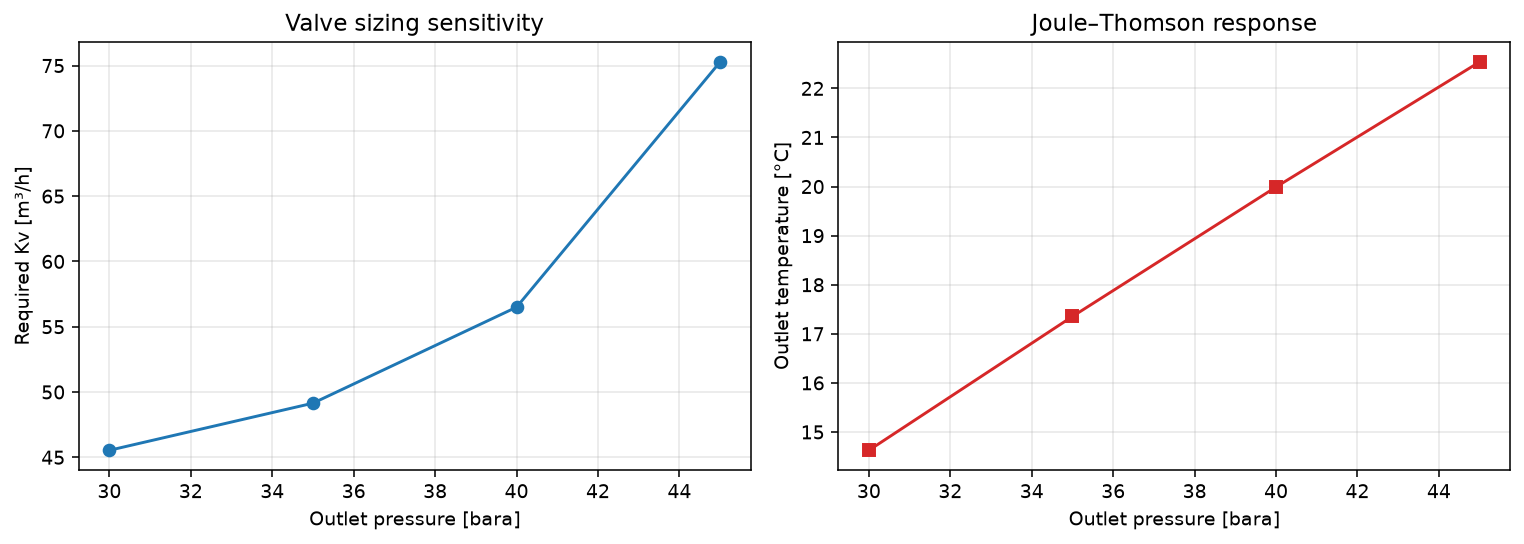

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    valve_sensitivity["Outlet pressure [bara]"],
    valve_sensitivity["Kv [m³/h]"],
    marker="o",
)
axes[0].set_xlabel("Outlet pressure [bara]")
axes[0].set_ylabel("Required Kv [m³/h]")
axes[0].set_title("Valve sizing sensitivity")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    valve_sensitivity["Outlet pressure [bara]"],
    valve_sensitivity["Outlet temperature [°C]"],
    marker="s",
    color="tab:red",
)
axes[1].set_xlabel("Outlet pressure [bara]")
axes[1].set_ylabel("Outlet temperature [°C]")
axes[1].set_title("Joule–Thomson response")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


A smaller pressure drop needs a larger coefficient to pass the same gas flow. The temperature
approaches the inlet temperature as the letdown decreases. None of these cases is choked for the
illustrative $x_T$; changing trim can change that conclusion.

## 10. Pipe-diameter sensitivity

Velocity varies with $D^{-2}$, so fittings become very sensitive to diameter. Properties are held
at the inlet state to reveal the hydraulic scaling; a long line would need pressure-dependent
segmentation.


In [11]:
diameter_rows = []

for trial_diameter in [0.15, 0.18, 0.20, 0.22, 0.25]:
    loss_result = calculate_pipe_losses(trial_diameter, feed_mass_flow)
    diameter_rows.append(
        {
            "Diameter [m]": trial_diameter,
            **loss_result,
        }
    )

diameter_sensitivity = pd.DataFrame(diameter_rows)
display(
    diameter_sensitivity[
        [
            "Diameter [m]",
            "Velocity [m/s]",
            "Reynolds number [-]",
            "Total loss [bar]",
        ]
    ]
)


,Diameter [m],Velocity [m/s],Reynolds number [-],Total loss [bar]
0,0.15,12.227391,6.208464e+06,0.193558
1,0.18,8.491244,5.173720e+06,0.084440
2,0.20,6.877908,4.656348e+06,0.052581
3,0.22,5.684221,4.233044e+06,0.034375
4,0.25,4.401861,3.725078e+06,0.019537


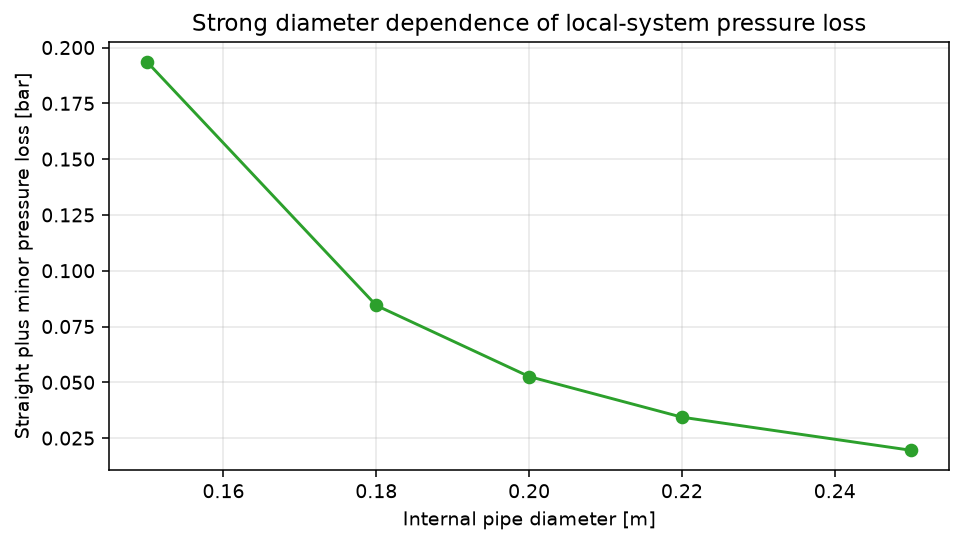

In [12]:
fig, axis = plt.subplots(figsize=(7, 4))
axis.plot(
    diameter_sensitivity["Diameter [m]"],
    diameter_sensitivity["Total loss [bar]"],
    marker="o",
    color="tab:green",
)
axis.set_xlabel("Internal pipe diameter [m]")
axis.set_ylabel("Straight plus minor pressure loss [bar]")
axis.set_title("Strong diameter dependence of local-system pressure loss")
axis.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 11. Orifice-bore sensitivity

An undersized bore produces a rapidly rising differential pressure and may violate ISO 5167
beta-ratio, Reynolds-number, or differential-pressure limits. The sensitivity below keeps the
NeqSim upstream properties fixed and solves each restriction independently.


In [13]:
orifice_rows = []

for trial_orifice_diameter in [0.10, 0.11, 0.12, 0.13, 0.14]:
    trial_downstream_pressure = differential_pressure_meter_solver(
        D=pipe_diameter,
        D2=trial_orifice_diameter,
        P1=feed.getPressure("Pa"),
        P2=None,
        m=feed_mass_flow,
        rho=feed_density,
        mu=feed_viscosity,
        k=feed_kappa,
        meter_type="ISO 5167 orifice",
        taps="D",
    )
    trial_pressure_drop = (
        feed.getPressure("Pa") - trial_downstream_pressure
    ) / 1.0e5
    orifice_rows.append(
        {
            "Orifice diameter [m]": trial_orifice_diameter,
            "Beta ratio [-]": trial_orifice_diameter / pipe_diameter,
            "Differential pressure [bar]": trial_pressure_drop,
        }
    )

orifice_sensitivity = pd.DataFrame(orifice_rows)
display(orifice_sensitivity)


,Orifice diameter [m],Beta ratio [-],Differential pressure [bar]
0,0.10,0.50,0.412606
1,0.11,0.55,0.271152
2,0.12,0.60,0.182373
3,0.13,0.65,0.124399
4,0.14,0.70,0.085391


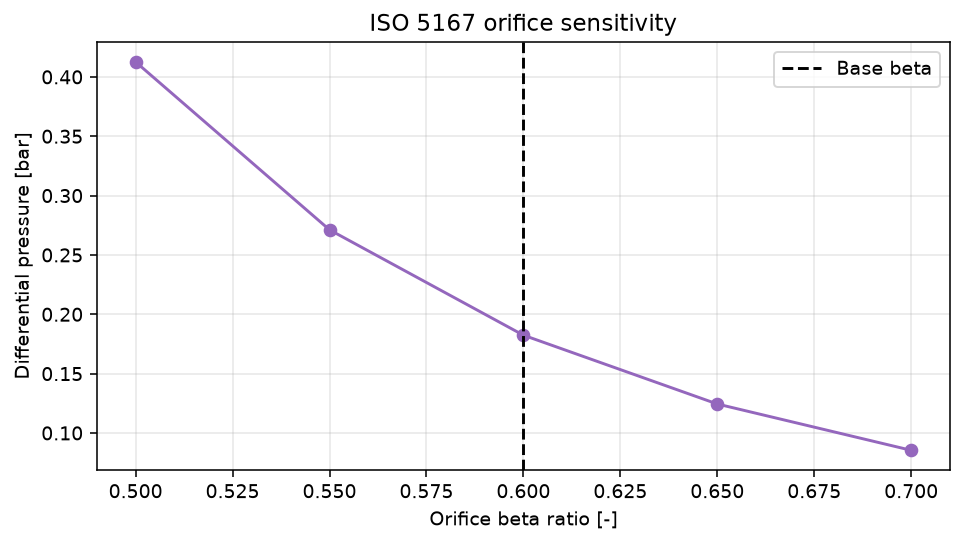

In [14]:
fig, axis = plt.subplots(figsize=(7, 4))
axis.plot(
    orifice_sensitivity["Beta ratio [-]"],
    orifice_sensitivity["Differential pressure [bar]"],
    marker="o",
    color="tab:purple",
)
axis.axvline(0.60, color="black", linestyle="--", label="Base beta")
axis.set_xlabel("Orifice beta ratio [-]")
axis.set_ylabel("Differential pressure [bar]")
axis.set_title("ISO 5167 orifice sensitivity")
axis.grid(True, alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()


## 12. Focused verification

The checks below test composition closure, phase state, finite properties, isenthalpic behavior,
unit conversion, independent IEC agreement, turbulent-flow assumptions, pressure ordering, and
expected sensitivity trends. Assertions are deliberately tied to engineering identities rather
than frozen last digits.


In [15]:
checks = {
    "NeqSim 3.x installed": neqsim_version.startswith("3."),
    "composition closes": abs(sum(composition.values()) - 1.0) < 1.0e-12,
    "single gas phase": feed_phase_count == 1,
    "positive mass flow": feed_mass_flow > 0.0,
    "positive density": feed_density > 0.0,
    "positive viscosity": feed_viscosity > 0.0,
    "real-gas Z plausible": 0.5 < feed_z < 1.2,
    "heat-capacity ratio plausible": 1.0 < feed_kappa < 2.0,
    "valve pressure decreases": valve.getOutletStream().getPressure("bara") < 50.0,
    "valve mass closes": abs(
        valve.getOutletStream().getFlowRate("kg/sec") - feed_mass_flow
    ) < 1.0e-9,
    "valve enthalpy closes": abs(enthalpy_residual) < 1.0e-4,
    "Kv positive": neqsim_kv > 0.0,
    "Cv conversion closes": abs(neqsim_cv / neqsim_kv - 1.156) < 1.0e-12,
    "NeqSim valve is non-choked": not bool(valve_sizing["choked"]),
    "independent valve is non-choked": not bool(independent_valve["choked"]),
    "independent Kv agrees": kv_difference_percent < 5.0,
    "standard flow positive": standard_volume_flow > 0.0,
    "pipe flow turbulent": base_pipe_losses["Reynolds number [-]"] > 1.0e5,
    "pipe velocity positive": base_pipe_losses["Velocity [m/s]"] > 0.0,
    "straight loss positive": base_pipe_losses["Straight loss [bar]"] > 0.0,
    "minor loss positive": base_pipe_losses["Minor loss [bar]"] > 0.0,
    "orifice pressure ordered": 0.0 < orifice_downstream_pressure < feed.getPressure("Pa"),
    "orifice beta valid here": 0.50 <= orifice_beta <= 0.75,
    "orifice differential positive": orifice_pressure_drop > 0.0,
    "Kv rises with outlet pressure": np.all(
        np.diff(valve_sensitivity["Kv [m³/h]"]) > 0.0
    ),
    "temperature rises with outlet pressure": np.all(
        np.diff(valve_sensitivity["Outlet temperature [°C]"]) > 0.0
    ),
    "pipe loss falls with diameter": np.all(
        np.diff(diameter_sensitivity["Total loss [bar]"]) < 0.0
    ),
    "orifice differential falls with bore": np.all(
        np.diff(orifice_sensitivity["Differential pressure [bar]"]) < 0.0
    ),
    "all valve sensitivity values finite": np.isfinite(
        valve_sensitivity.select_dtypes(include="number").to_numpy()
    ).all(),
    "all hydraulic sensitivity values finite": np.isfinite(
        diameter_sensitivity.select_dtypes(include="number").to_numpy()
    ).all(),
}

failed_checks = [name for name, passed in checks.items() if not passed]

if failed_checks:
    raise AssertionError(f"Failed engineering checks: {failed_checks}")

print(f"All {len(checks)} engineering checks passed.")


All 30 engineering checks passed.


## 13. Applicability, limitations, and troubleshooting

Use this workflow for preliminary pressure-loss allocation, valve duty definition, and meter
screening. Do not use it alone for final procurement or safety verification.

Important limitations:

- IEC valve sizing requires the actual trim, $x_T$, $F_L$, $F_d$, reducer geometry, and vendor
  capacity data. Check noise, vibration, flashing, cavitation, erosion, and actuator margins.
- ISO 5167 imposes geometry, tap, Reynolds-number, straight-run, edge-quality, and beta limits.
- Handbook $K$ values depend on geometry and opening. A control valve should not be represented
  by a generic minor-loss coefficient when its capacity curve is available.
- Constant-property Darcy calculations are unsuitable for large gas pressure changes. Segment
  the line and update properties, or use a NeqSim pipeline model.
- Multiphase, transient, pulsating, erosive, or near-critical flow requires a more detailed model.

Troubleshooting:

- If the valve solver reports choking, verify absolute pressures and the vendor $x_T$.
- If the ISO solver fails, check SI units, beta ratio, Reynolds number, and pressure ordering.
- If pressure losses look excessive, inspect diameter units and standard versus actual flow.
- If phases appear unexpectedly, plot a phase envelope and select an appropriate EOS or CPA.


In [16]:
summary_table = pd.DataFrame(
    {
        "Result": [
            "NeqSim valve Kv",
            "Independent valve Kv",
            "Valve outlet temperature",
            "Valve enthalpy residual",
            "Pipe and fitting pressure loss",
            "Orifice differential pressure",
        ],
        "Value": [
            neqsim_kv,
            independent_kv,
            outlet_temperature,
            enthalpy_residual,
            base_pipe_losses["Total loss [bar]"],
            orifice_pressure_drop,
        ],
        "Unit": ["m³/h", "m³/h", "°C", "J/mol", "bar", "bar"],
    }
)
display(summary_table)


,Result,Value,Unit
0,NeqSim valve Kv,4.914266e+01,m³/h
1,Independent valve Kv,4.758183e+01,m³/h
2,Valve outlet temperature,1.735332e+01,°C
3,Valve enthalpy residual,8.943942e-09,J/mol
4,Pipe and fitting pressure loss,5.258102e-02,bar
5,Orifice differential pressure,1.823733e-01,bar


## 14. Summary, exercises, and references

The worked case connected one consistent NeqSim real-gas state to an IEC 60534 valve, a
Darcy/minor-loss system, and an ISO 5167 orifice. The valve cooled the gas isenthalpically, the
independent valve implementation agreed within a few percent, and both diameter studies showed
the expected nonlinear hydraulic response.

Suggested exercises:

1. Replace the illustrative valve $x_T$ with a vendor value and identify the choking boundary.
2. Add inlet and outlet reducers and compare corrected with line-size valve capacity.
3. Repeat the pipe calculation with pressure-segmented NeqSim properties.
4. Change to a wet gas near its dew point and test whether a liquid phase appears after letdown.
5. Compare an orifice plate with a venturi meter at the same mass flow.

Authoritative and implementation references:

- [NeqSim valve equipment guide](https://github.com/equinor/neqsim/blob/master/docs/process/equipment/valves.md)
- [NeqSim control-valve guide](https://github.com/equinor/neqsim/blob/master/docs/process/equipment/control_valves.md)
- [NeqSim process equipment documentation](https://equinor.github.io/neqsim/process/README.html)
- [NeqSim thermodynamic operations guide](https://equinor.github.io/neqsim/thermodynamicoperations/README.html)
- [fluids control-valve documentation](https://fluids.readthedocs.io/fluids.control_valve.html)
- [fluids differential-pressure meter documentation](https://fluids.readthedocs.io/fluids.flow_meter.html)
- IEC 60534-2-1, *Industrial-process control valves: Flow capacity sizing equations*
- ISO 5167-2, *Measurement of fluid flow by pressure differential devices: Orifice plates*
